## Импорт основных библиотек

In [32]:
# Необходимо для корректной работы внешних .py файлов
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import pandas as pd
import seaborn as sns
from helper import *
from plots import *
import random

In [34]:
# фиксируем состояние генератора псевдослучайных чисел. Это необходимо, чтобы результаты модели не менялись с каждым новым запуском 
SEED = 42 # можно указать любое число
np.random.seed(SEED)
random.seed(SEED)

##  1. Изучение структуры данных

In [35]:
# Загружаем датасет в память
df = pd.read_csv("diamonds.csv", index_col=0)
df.head(5)

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [36]:
# Смотрим на детали
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 1 to 53940
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  str    
 2   color    53940 non-null  str    
 3   clarity  53940 non-null  str    
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 4.1 MB


Пропущенных значений не имеется

In [37]:
# Смотрим на статистики по числовым переменным (категориальные сюда не входят)
df.describe()

,carat,depth,table,price,x,y,z
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,3932.799722,5.731157,5.734526,3.538734
std,0.474011,1.432621,2.234491,3989.439738,1.121761,1.142135,0.705699
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.250000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


## 2. Проверка на корректность и качество данных

### 2.1 Проверка на дубликаты

In [38]:
# Подсчет числа дублированных строк
df.duplicated().sum() 

np.int64(146)

### 2.2 Пропущенные значения

In [39]:
# выводим число пропущенных значений по каждому столбцу
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

## 3. Детальное изучение признаков (и таргета)

### 3.1 Числовые переменные

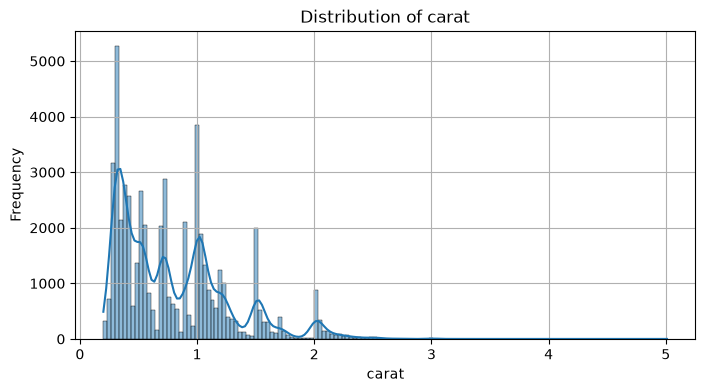

In [40]:
# Строим гистограмму распределения carat
plot_hist_numeric(df, 'carat')

Видно, что есть пики в районе 0.3, 1, 1.5 и 2 карат

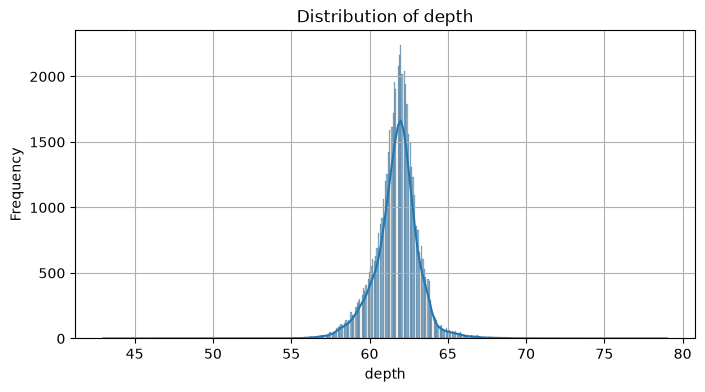

In [41]:
# Строим гистограмму распределения depth
plot_hist_numeric(df, 'depth')

Видно, что значения сконцентрировались в диапазоне 55-67 процентов. Остальные можно считать выбросами

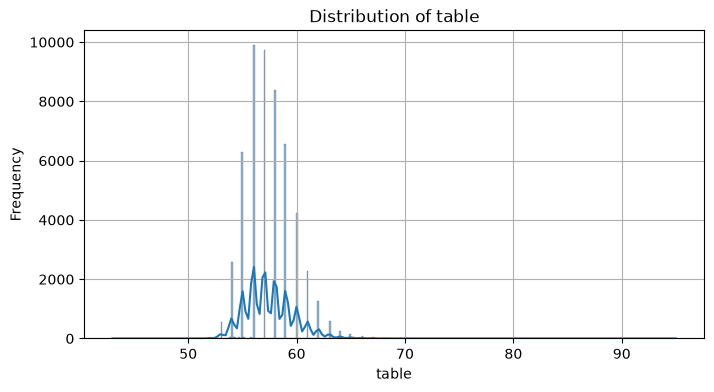

In [42]:
# Строим гистограмму распределения table
plot_hist_numeric(df, 'table')

Видно, что в целом распределение выглядит как нормальное, но значения округлялись. Значения лежат в диапазоне 50-65 процентов

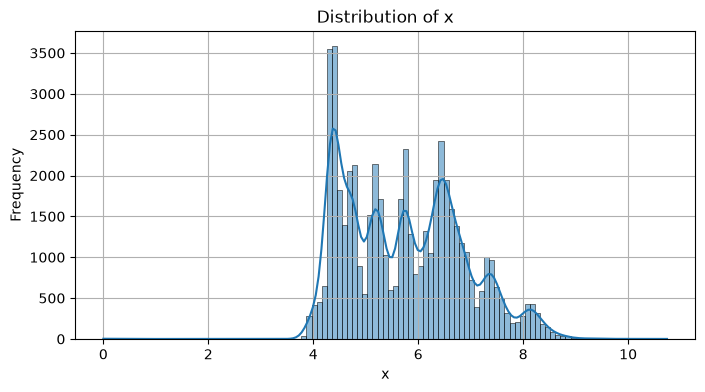

In [43]:
# Строим гистограмму распределения x
plot_hist_numeric(df, 'x')

Длина может варьироваться, распределение ненормальное. Значения в диапазоне 4-9 мм

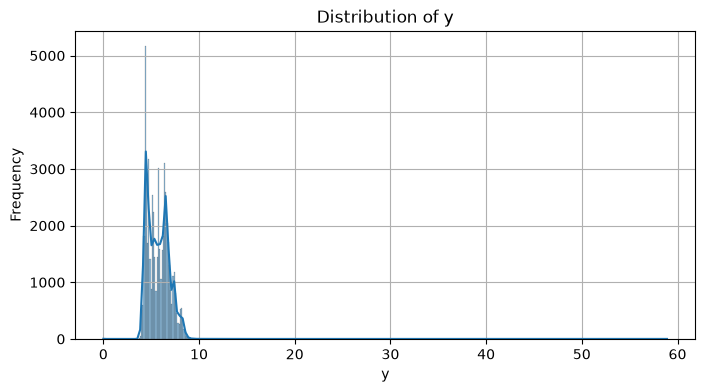

In [44]:
# Строим гистограмму распределения y (ширина)
plot_hist_numeric(df, 'y')

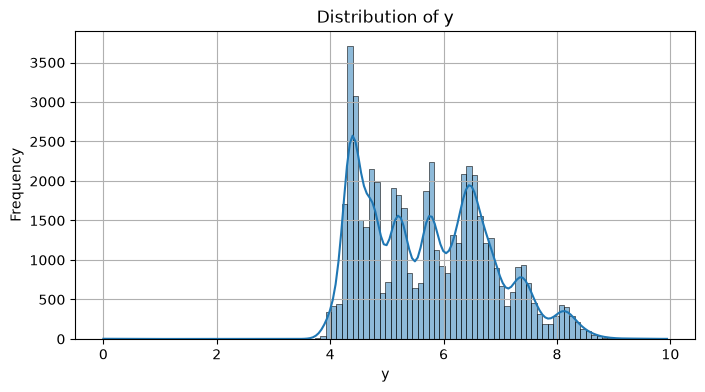

In [45]:
# Выведем значения между 0 и 10
df_filtered = df[df['y'].between(0, 10)]
plot_hist_numeric(df_filtered, 'y')

Имеются большие выбросы, распределение также ненормальное, похоже на 'x' (длина). Значения в диапазоне 4-9 мм

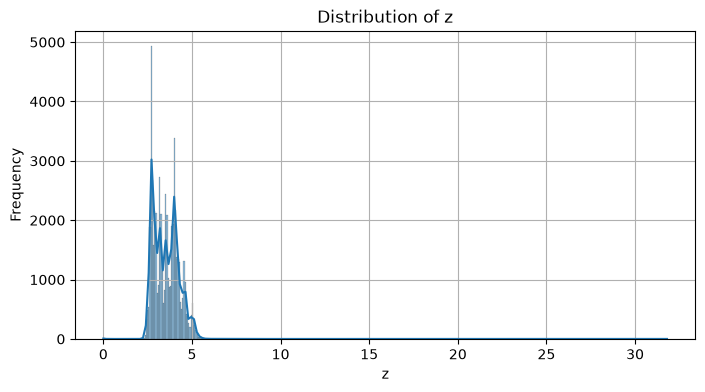

In [46]:
# Строим гистограмму распределения z (высота)
plot_hist_numeric(df, 'z')

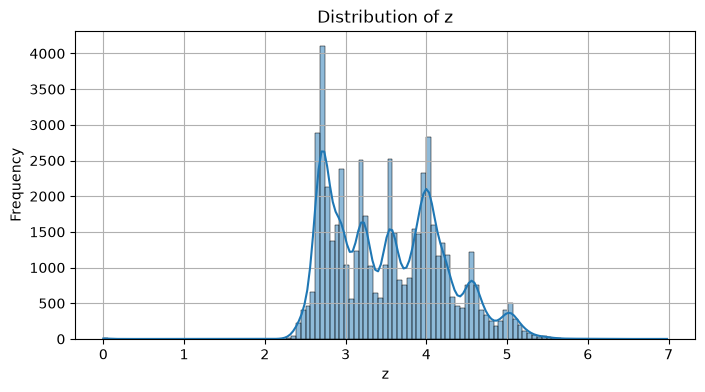

In [47]:
# Выведем значения между 0 и 10
df_filtered = df[df['z'].between(0, 7)]
plot_hist_numeric(df_filtered, 'z')

Распределение похоже на предыдущие 'x' и 'y' (длина и ширина соответственно), однако значения немного сдвинуты на ~2мм. Значения в диапазоне 2-6 мм

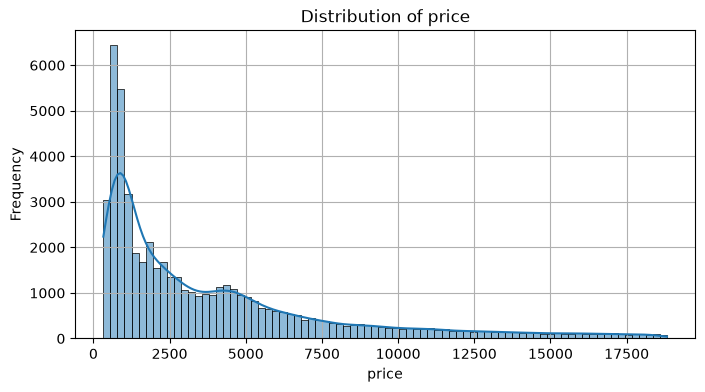

In [48]:
# Строим гистограмму распределения price (наш таргет)
plot_hist_numeric(df, 'price')

Имеется сильный перекос, большинство значений лежат от 0 до 8000$

### 3.2 Категориальные переменные

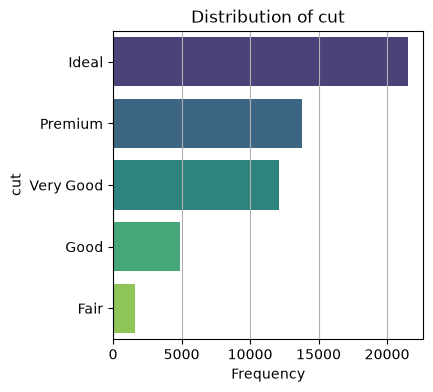

In [49]:
# Строим гистограмму распределения cut
plot_hist_categorical(df, 'cut')

Большинство строк с идеальным качеством огранки, мало значений с нормальным (Fair)

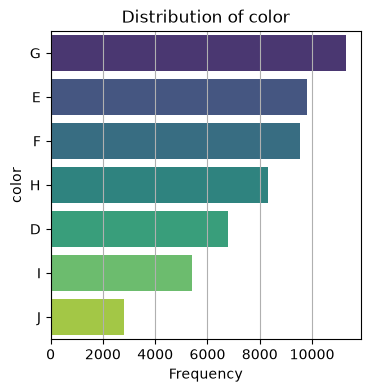

In [50]:
# Строим гистограмму распределения color
plot_hist_categorical(df, 'color')

| Категория | Описание |
|------------|----------|
| `D` | Абсолютно бесцветный. Наивысшая категория цвета, самые редкие и дорогие бриллианты. |
| `E` | Практически бесцветный. Незначительные оттенки заметны только при профессиональной оценке. |
| `F` | Практически бесцветный. Очень высокое качество цвета. |
| `G` | Почти бесцветный. Легкий оттенок практически незаметен невооруженным глазом. |
| `H` | Почти бесцветный. Незначительный оттенок может быть заметен при сравнении с более качественными камнями. |
| `I` | Слабый желтоватый или коричневатый оттенок, заметный при внимательном рассмотрении. |
| `J` | Наиболее выраженный оттенок среди представленных в датасете. Такие бриллианты обычно имеют более низкую стоимость по сравнению с категориями `D–I`. |

В целом датасет содержит преимущественно бриллианты среднего качества по цвету

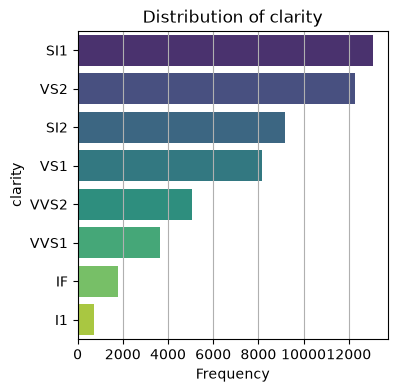

In [51]:
# Строим гистограмму распределения clarity
plot_hist_categorical(df, 'clarity')

| Категория | Описание |
|------------|----------|
| `IF` | **Internally Flawless** — внутренние дефекты отсутствуют, имеются лишь незначительные поверхностные несовершенства. Наивысшая категория чистоты в датасете. |
| `VVS1` | **Very Very Slightly Included 1** — крайне незначительные включения, практически незаметные даже при 10-кратном увеличении. |
| `VVS2` | **Very Very Slightly Included 2** — очень незначительные включения, немного более заметные, чем у `VVS1`. |
| `VS1` | **Very Slightly Included 1** — очень мелкие включения, трудно различимые при 10-кратном увеличении. |
| `VS2` | **Very Slightly Included 2** — небольшие включения, заметные специалисту при увеличении. |
| `SI1` | **Slightly Included 1** — небольшие включения, которые могут быть заметны при увеличении и иногда невооруженным глазом. |
| `SI2` | **Slightly Included 2** — включения более выражены, чем у `SI1`, и чаще заметны без увеличения. |
| `I1` | **Included 1** — заметные внутренние включения, влияющие на внешний вид и стоимость бриллианта. |

Распределение является неравномерным: большинство бриллиантов относятся к категориям средней чистоты (SI и VS), тогда как камни с очень высокой или низкой чистотой представлены существенно меньшим числом строк

## 4. Изучение взаимосвязей между признаками

### 4.1 Общая матрица корреляций

Наша цель состоит в том, чтобы понять, какие столбцы коррелируют друг с другом наиболее сильно и далее изучить подробнее эти корреляции. также понять, какие из столбцов сильнее всего коррелируют с таргетом

interval columns not set, guessing: ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']


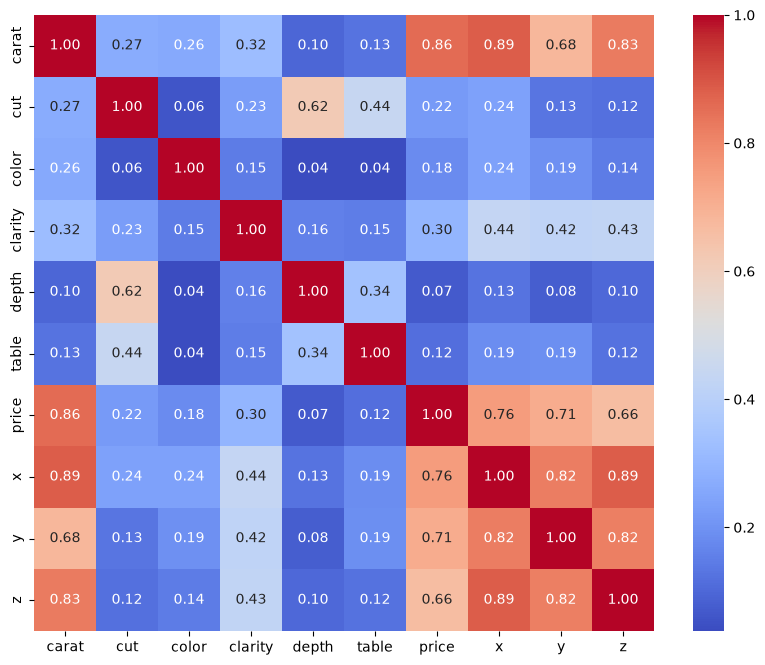

In [52]:
# поскольку в нашем датасете присутствуют категориальные признаки, используем корреляцию phik, которая способна с ними работать
plot_phik(df)

Обращаем внимание на ячейки с более высокими значениями корреляции. Видим, что наиболее сильные связки это: 
- price vs carat
- price vs clarity
- clarity vs x / y / z
- depth vs cut
- price vs x / y / z (аналогично с весом)
- carat vs x / y / z (вес зависит от размеро, логично)
- x vs y vs z (размеры друг от друга зависят)

### 4.2 Подробное изучение корреляций между выбранными парами

#### 4.2.1 marital-status vs age

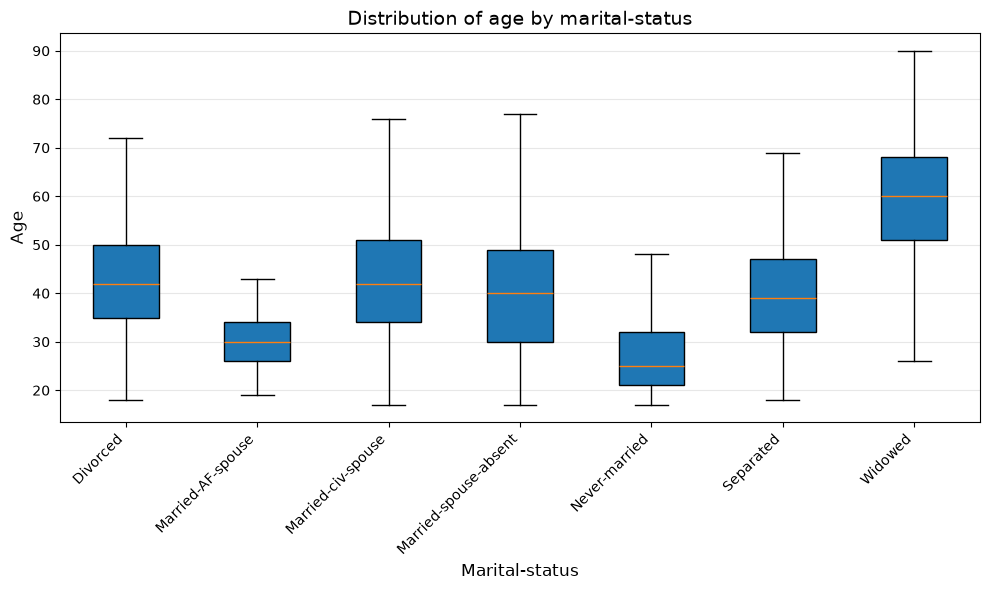

In [ ]:
plot_box_by_category(df, cat_feature="marital-status", num_feature="age", showfliers=False)

- Молодые люди чаще всего Never married.
- В среднем возрасте преобладают женатые.
- С возрастом растёт доля Divorced и особенно Widowed.

#### 4.2.2 occupation vs education

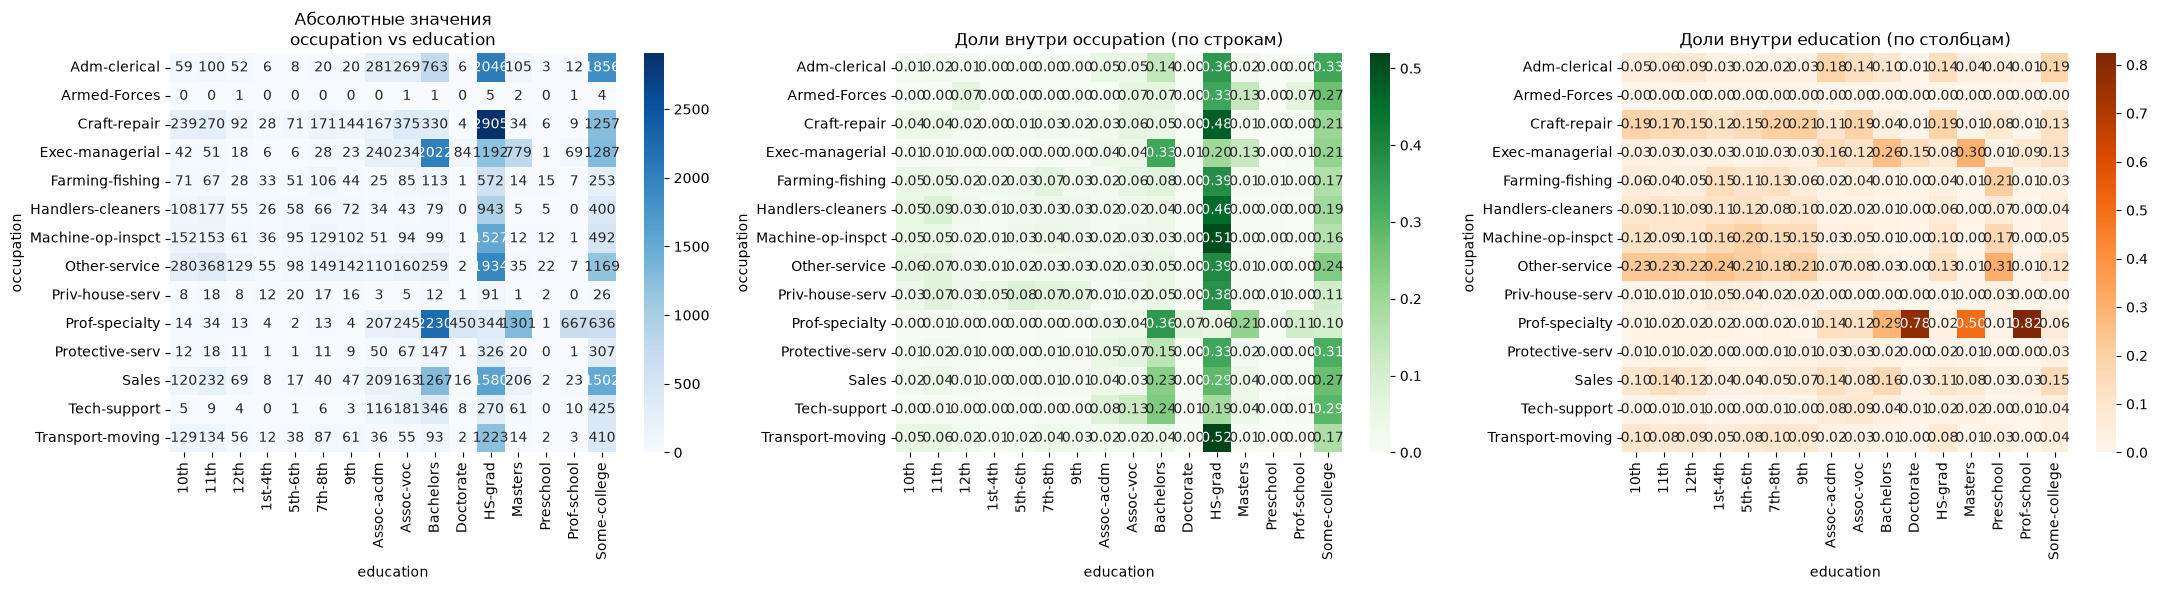

In [ ]:
plot_categorical_relationship(df, "occupation", "education")

- Люди с Doctorate, Prof-school и Masters почти полностью концентрируются в Prof-specialty.
- HS-grad - самая массовая категория образования, и она распределена очень широко по профессиям (особенно в рабочих специальностях).
- Очень мало людей с низким образованием (Preschool - 1st-4th) в престижных профессиях.

#### 4.2.3 relationship vs age

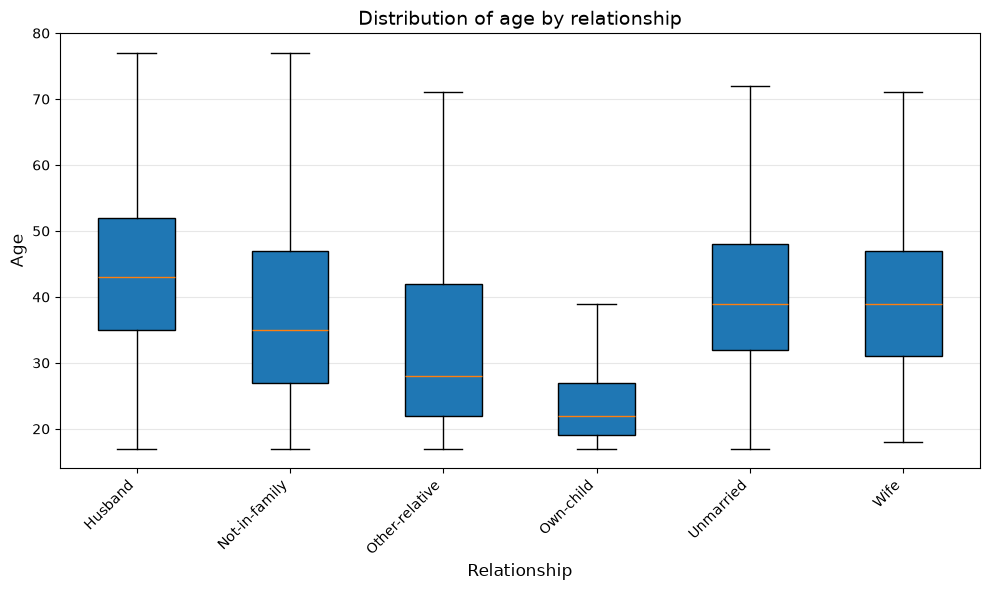

In [ ]:
plot_box_by_category(df, cat_feature="relationship", num_feature="age", showfliers=False)

- Молодые живут с родителями (Own-child).
- В зрелом возрасте люди становятся Husband / Wife.
- Много самостоятельных взрослых (Not-in-family, Unmarried).

#### 4.2.4 relationship vs marital-status

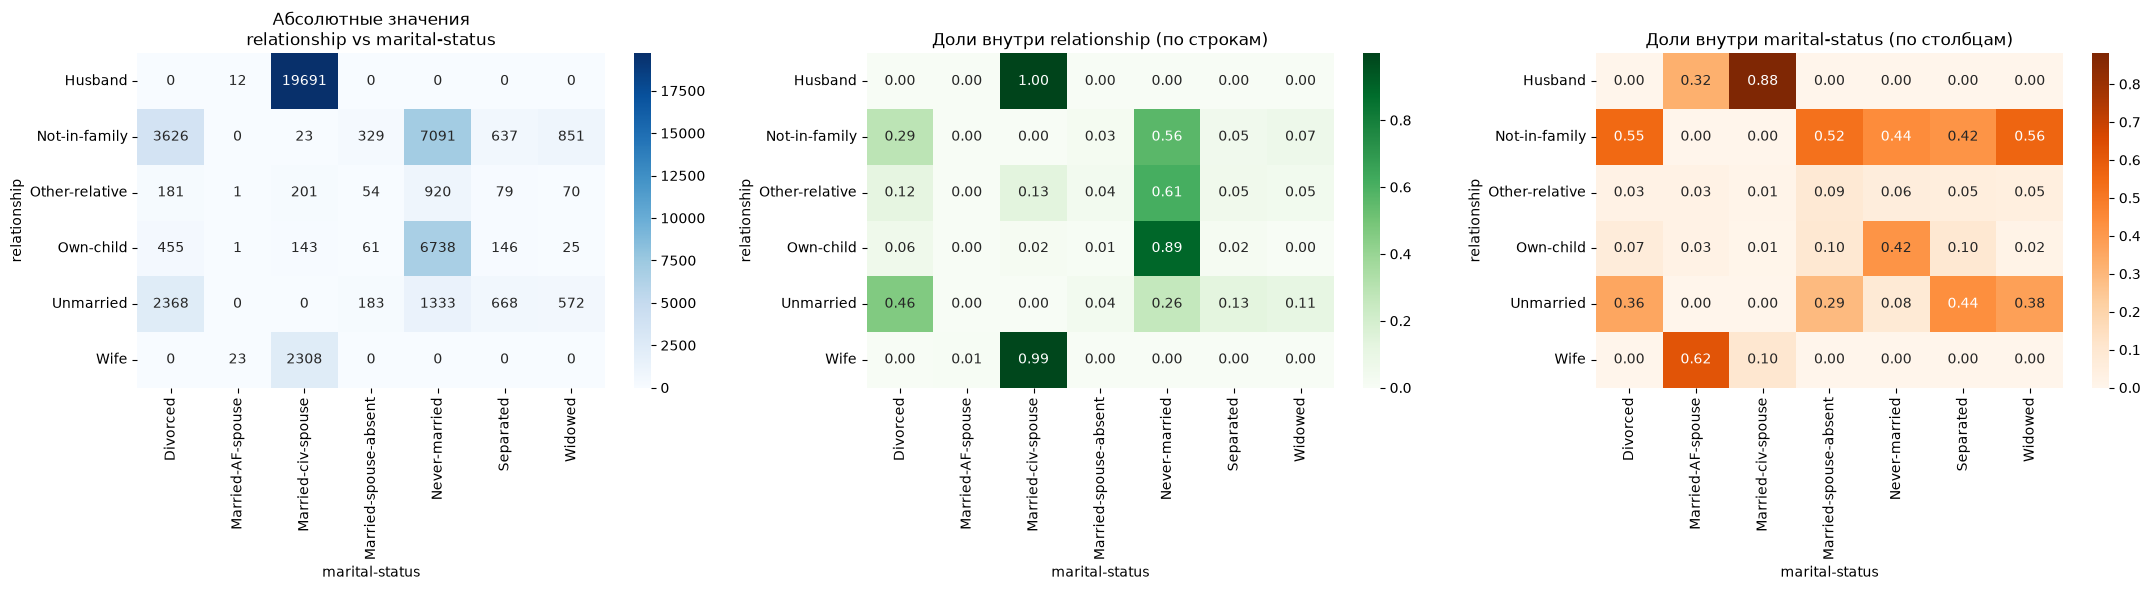

In [ ]:
plot_categorical_relationship(df, "relationship", "marital-status")

- Признаки relationship и marital-status очень сильно зависимы (фактически дублируют друг друга в многих категориях).
- Это ожидаемо: relationship описывает позицию человека внутри домохозяйства, а marital-status - официальный семейный статус.
- Можно один из этих двух признаков можно спокойно удалить - они несут почти одинаковую информацию.

#### 4.2.5 gender vs marital-status

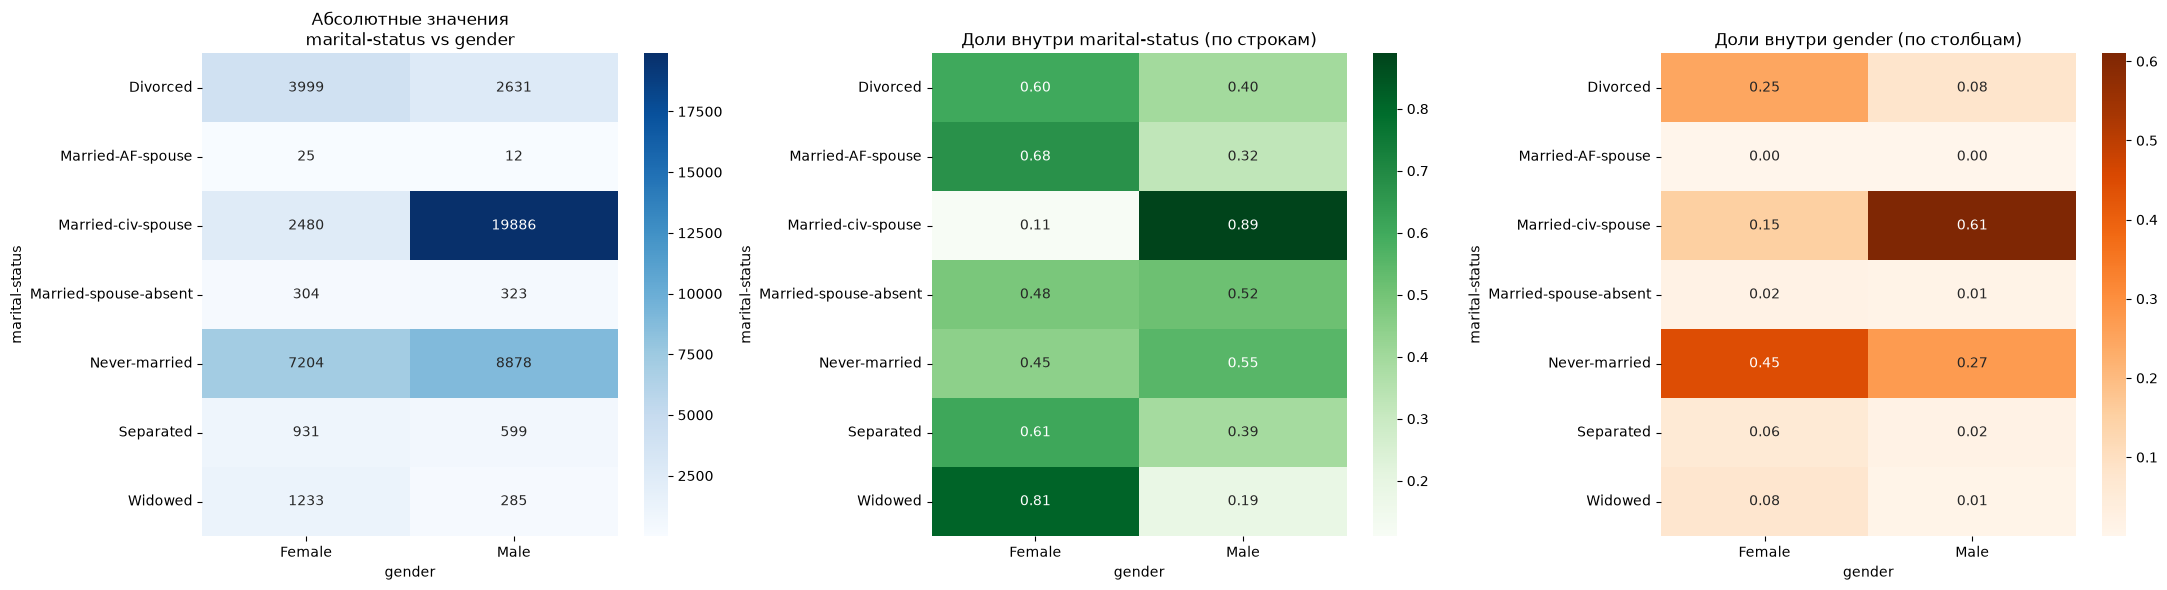

In [ ]:
plot_categorical_relationship(df, "marital-status", "gender")

- В датасете наблюдается сильное отклонение в сторону мужчин в категории "женат"
- Женщины более представлены в категориях, связанных с разрывом семьи или потерей супруга.

#### 4.2.6 gender vs occupation

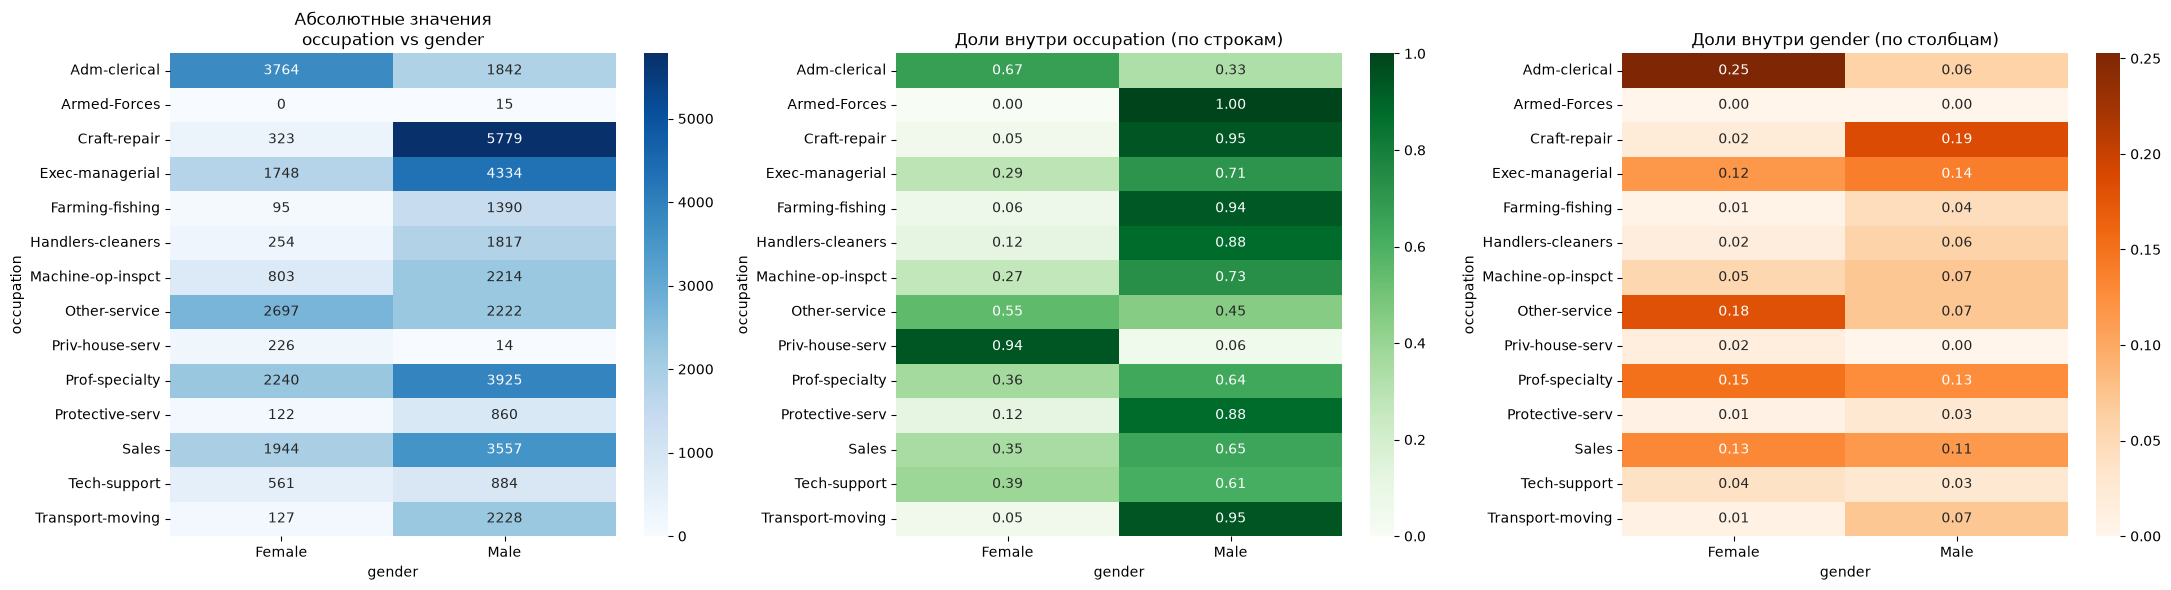

In [ ]:
plot_categorical_relationship(df, "occupation", "gender")

- Женщины доминируют в офисной, сервисной и домашней работе.
- Мужчины сильно преобладают в рабочих, технических, военных и транспортных специальностях.

#### 4.2.7 gender vs relationship

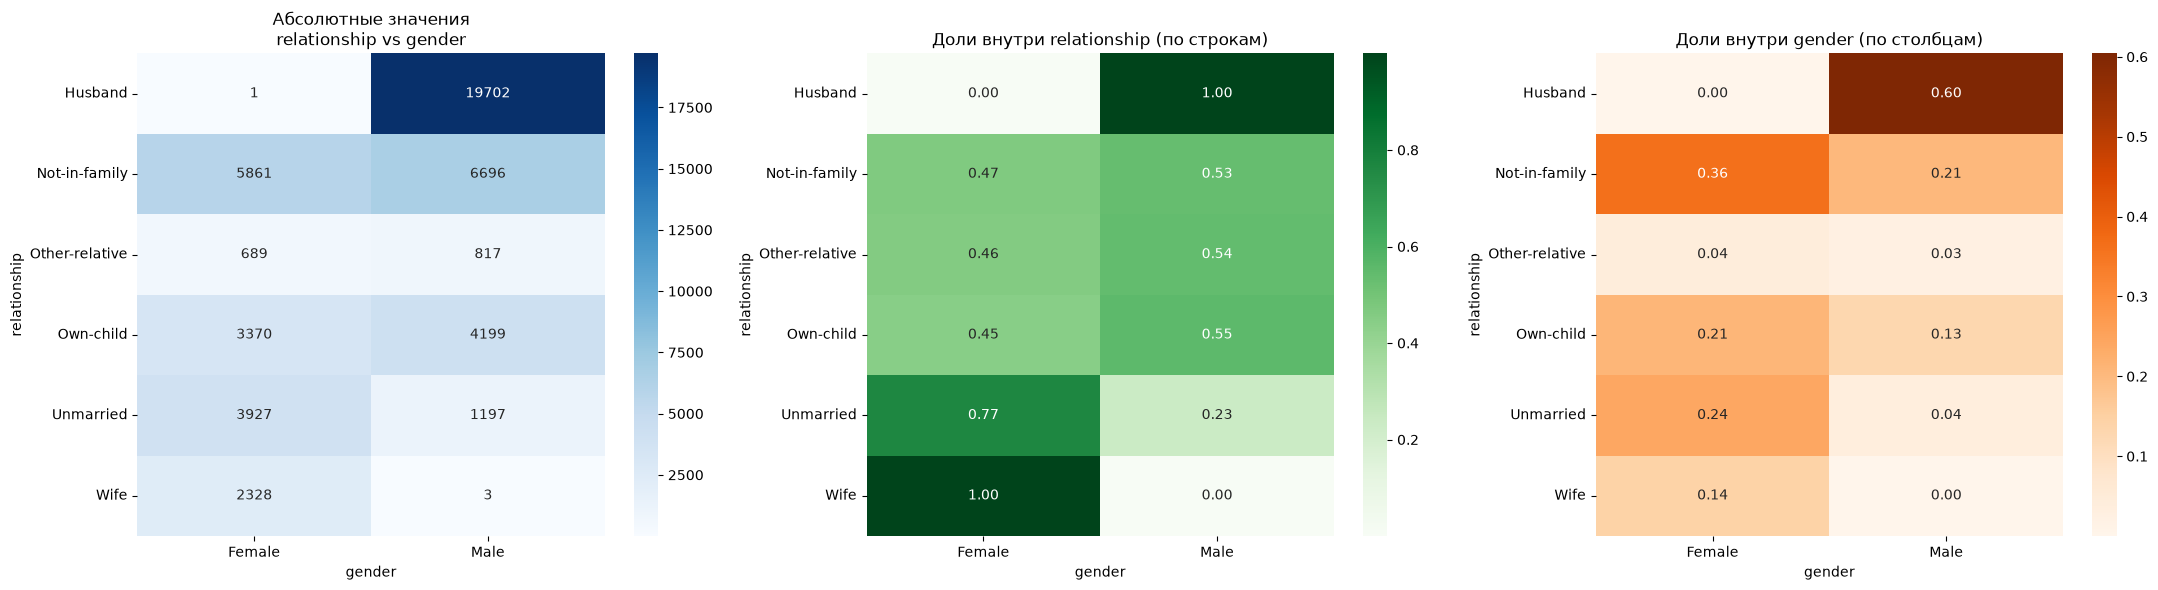

In [ ]:
plot_categorical_relationship(df, "relationship", "gender")

- Признак relationship очень тесно связан с gender. По сути, Husband и Wife - это гендерные версии семейного статуса.
- Женщины чаще встречаются в категориях Not-in-family и Unmarried.
- Мужчины доминируют в Husband.

#### 4.2.8 hours-per-week vs age

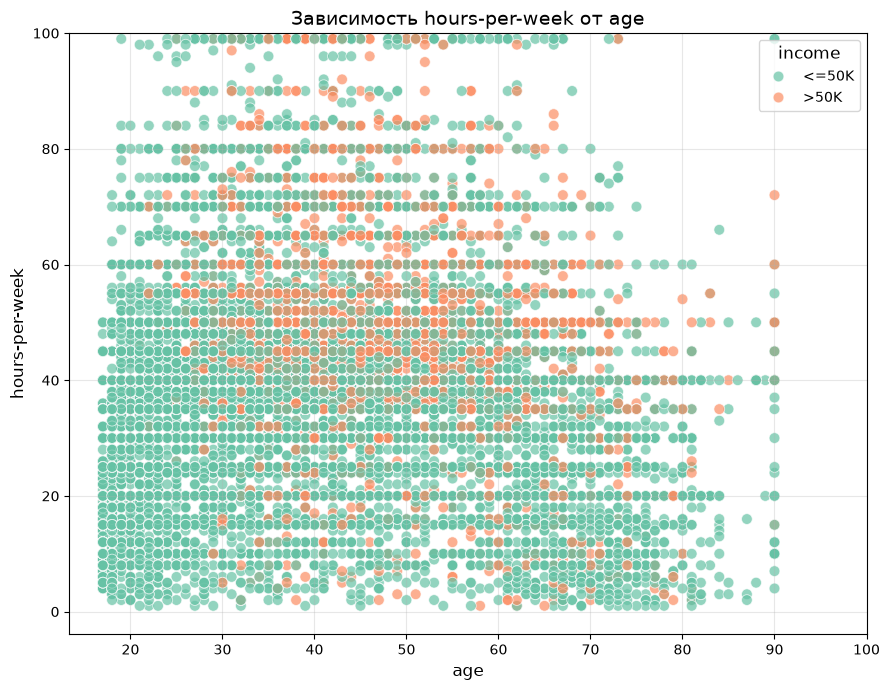

In [ ]:
plot_numeric_relationship(
    df, 
    "age", 
    "hours-per-week", 
    x_max=100,
    y_max=100,
    target_col="income",
)

- Количество рабочих часов - хороший предиктор высокого дохода. Люди, работающие больше 50 часов в неделю, имеют заметно больше шансов зарабатывать >50K.
- Существует сильная положительная связь между hours-per-week и income.
- Многие молодые люди (до 30 лет) работают мало часов, что объясняет их низкий доход.
- После 70 лет люди либо уходят на пенсию, либо переходят на частичную занятость.

#### 4.2.9 native-country vs education

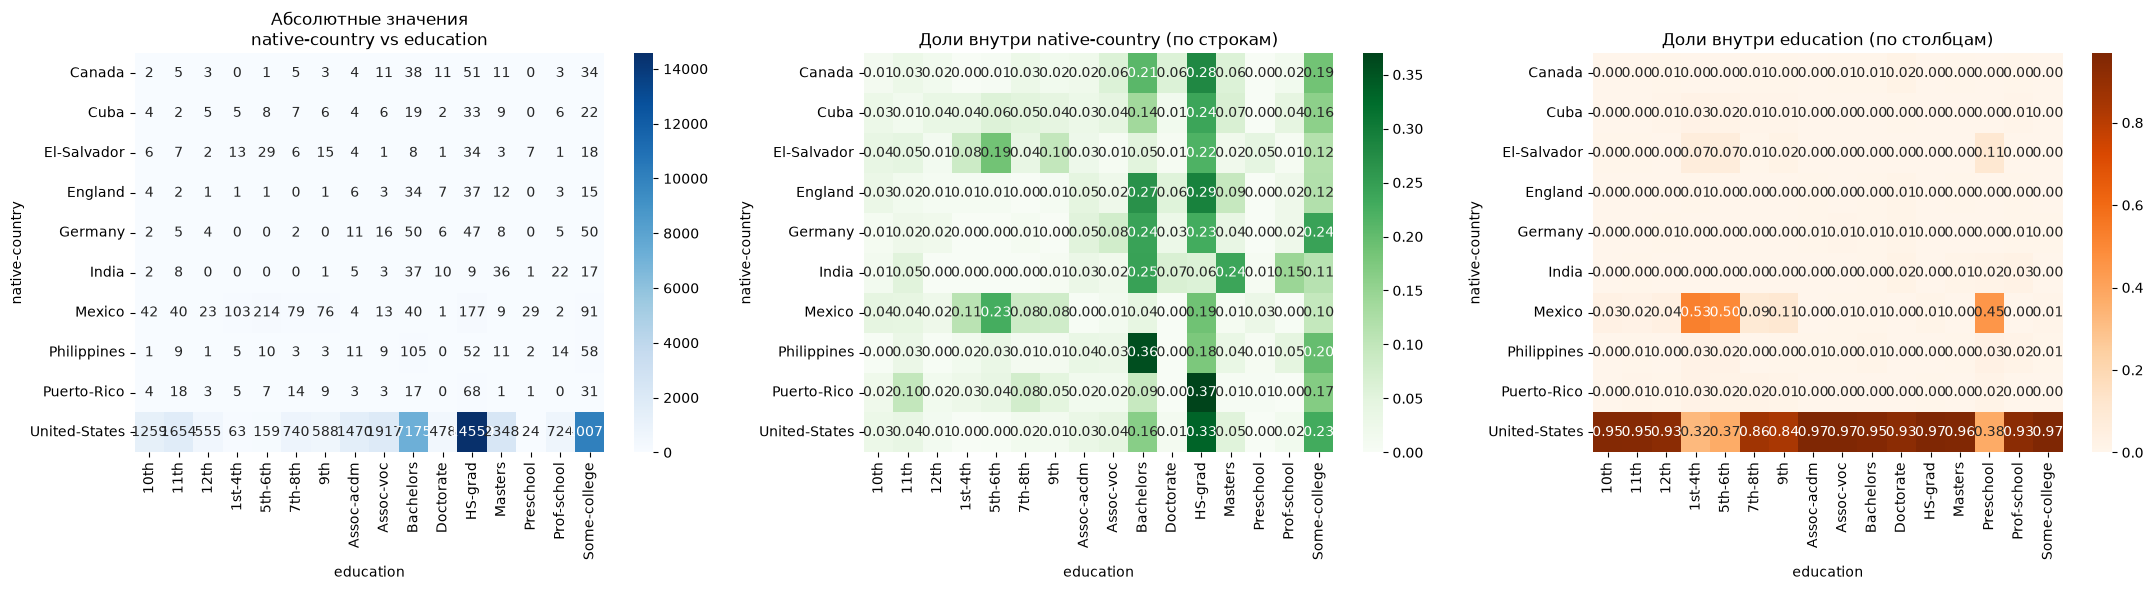

In [ ]:
top_10_countries = (df['native-country']
                    .value_counts()
                    .head(10)
                    .index.tolist())
df_top10 = df[df['native-country'].isin(top_10_countries)].copy()
plot_categorical_relationship(df_top10, "native-country", "education")

- Иммигранты из Мексики в среднем имеют значительно более низкое образование.
- Выходцы из Индии, Канады, Германии, Англии и Филиппин - одни из самых образованных групп.

#### 4.2.10 native-country vs race

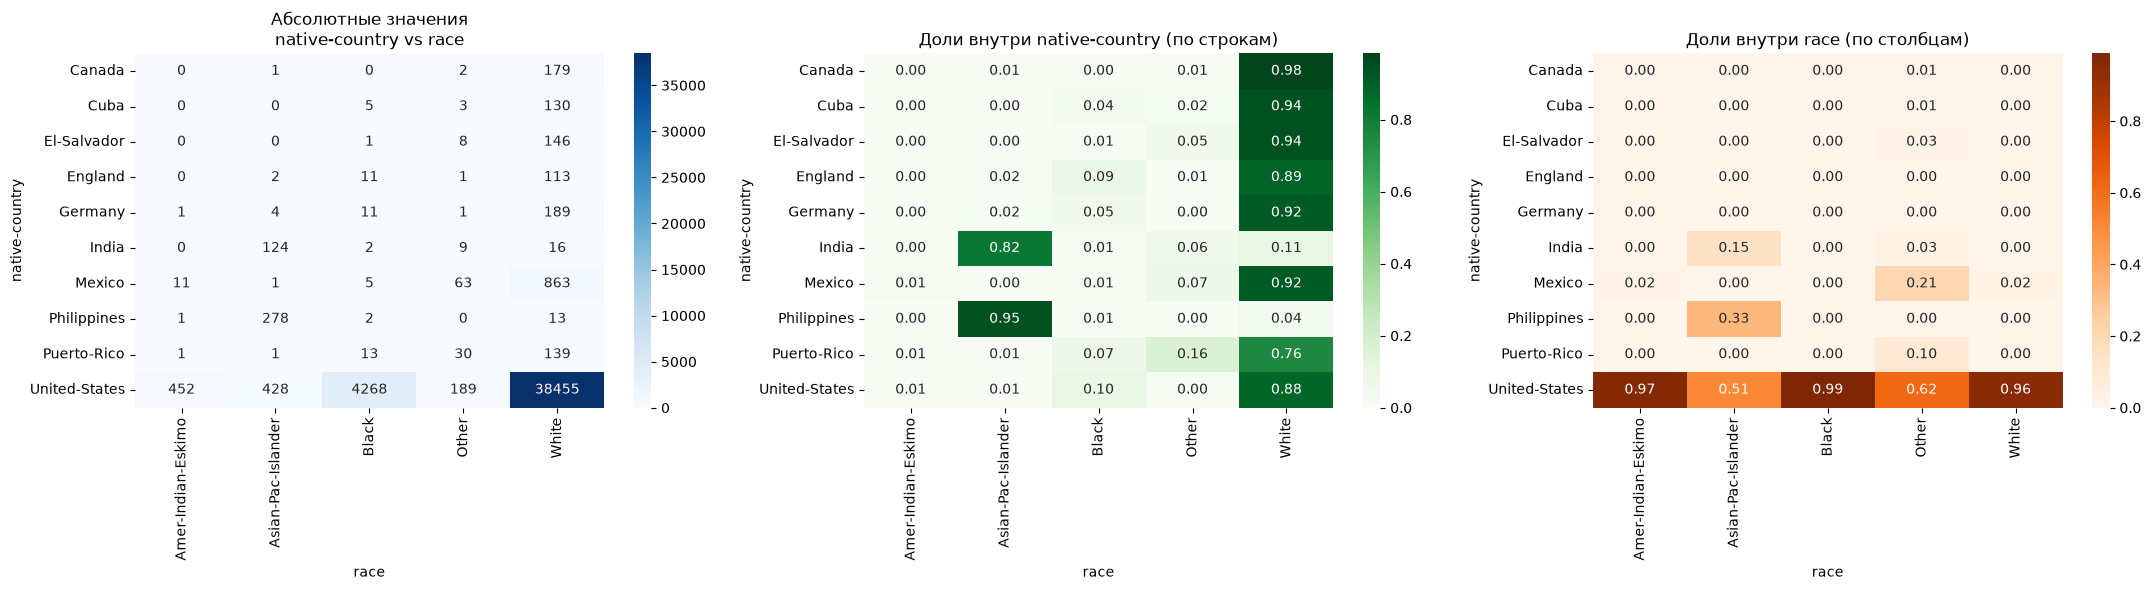

In [ ]:
plot_categorical_relationship(df_top10, "native-country", "race")

Здесь в целом ничего необычного - люди родом из разных стран имеют свою типичную расу

#### 4.2.11 income vs age 

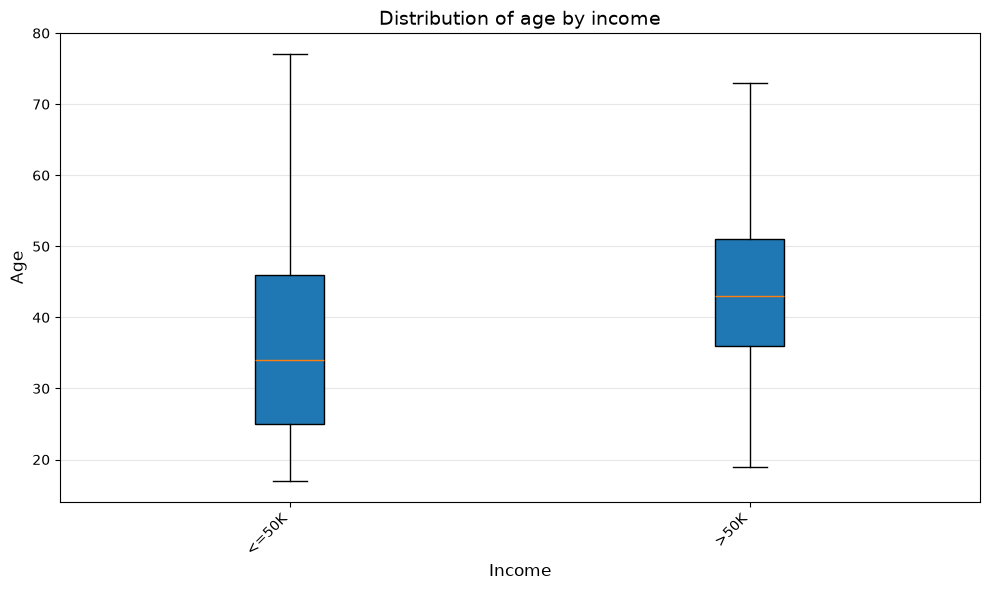

In [ ]:
plot_box_by_category(df, cat_feature="income", num_feature="age", showfliers=False)

В среднем более взрослые люди больше зарабатывают

#### 4.2.12 income vs education 

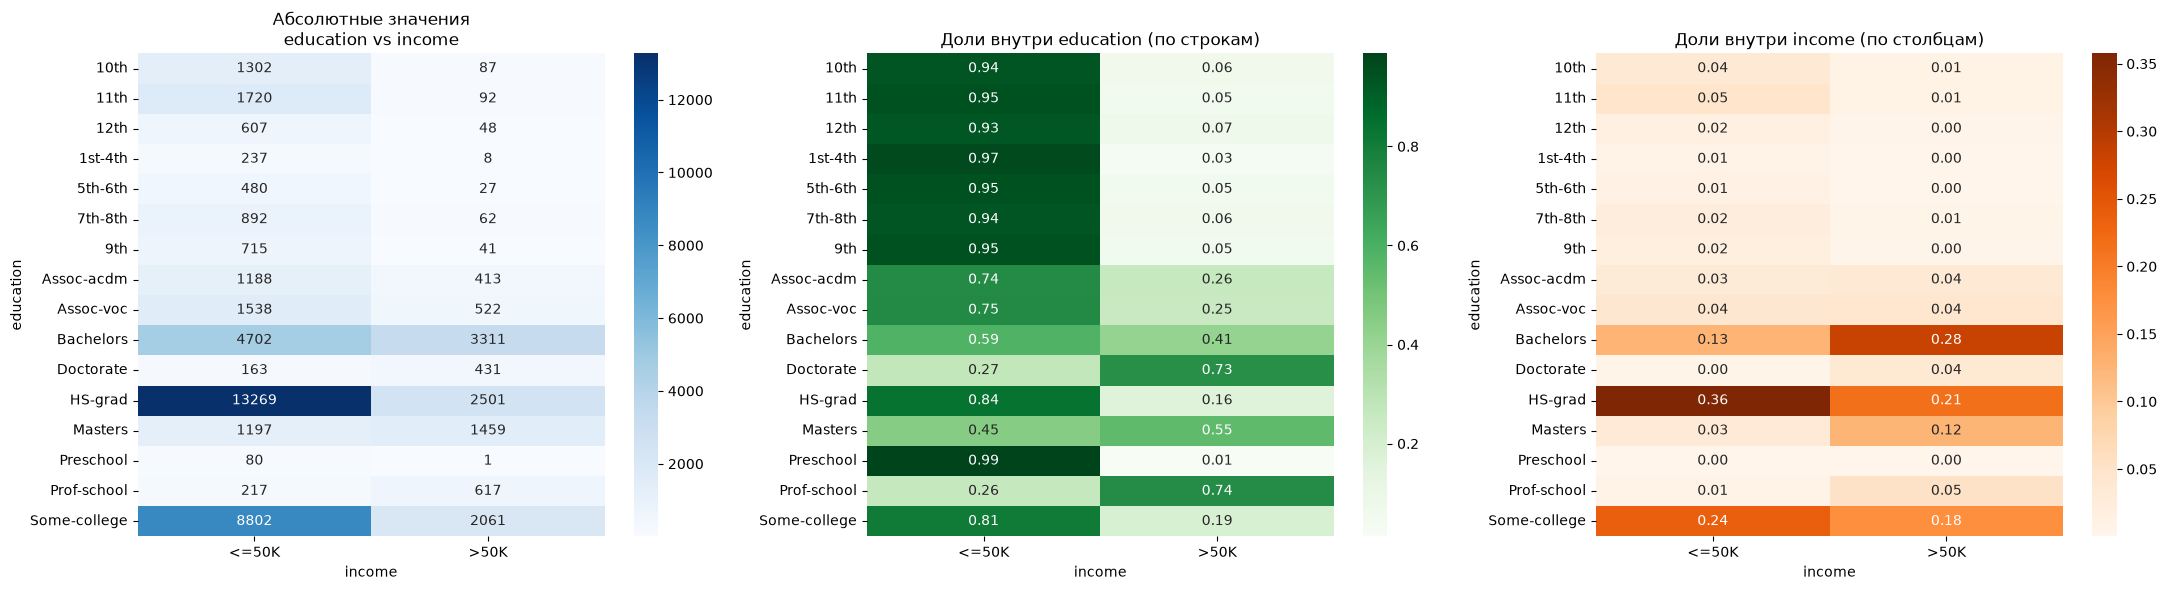

In [ ]:
plot_categorical_relationship(df, "education", "income")

Более образованные люди больше зарабатывают

#### 4.2.13 income vs marital-status

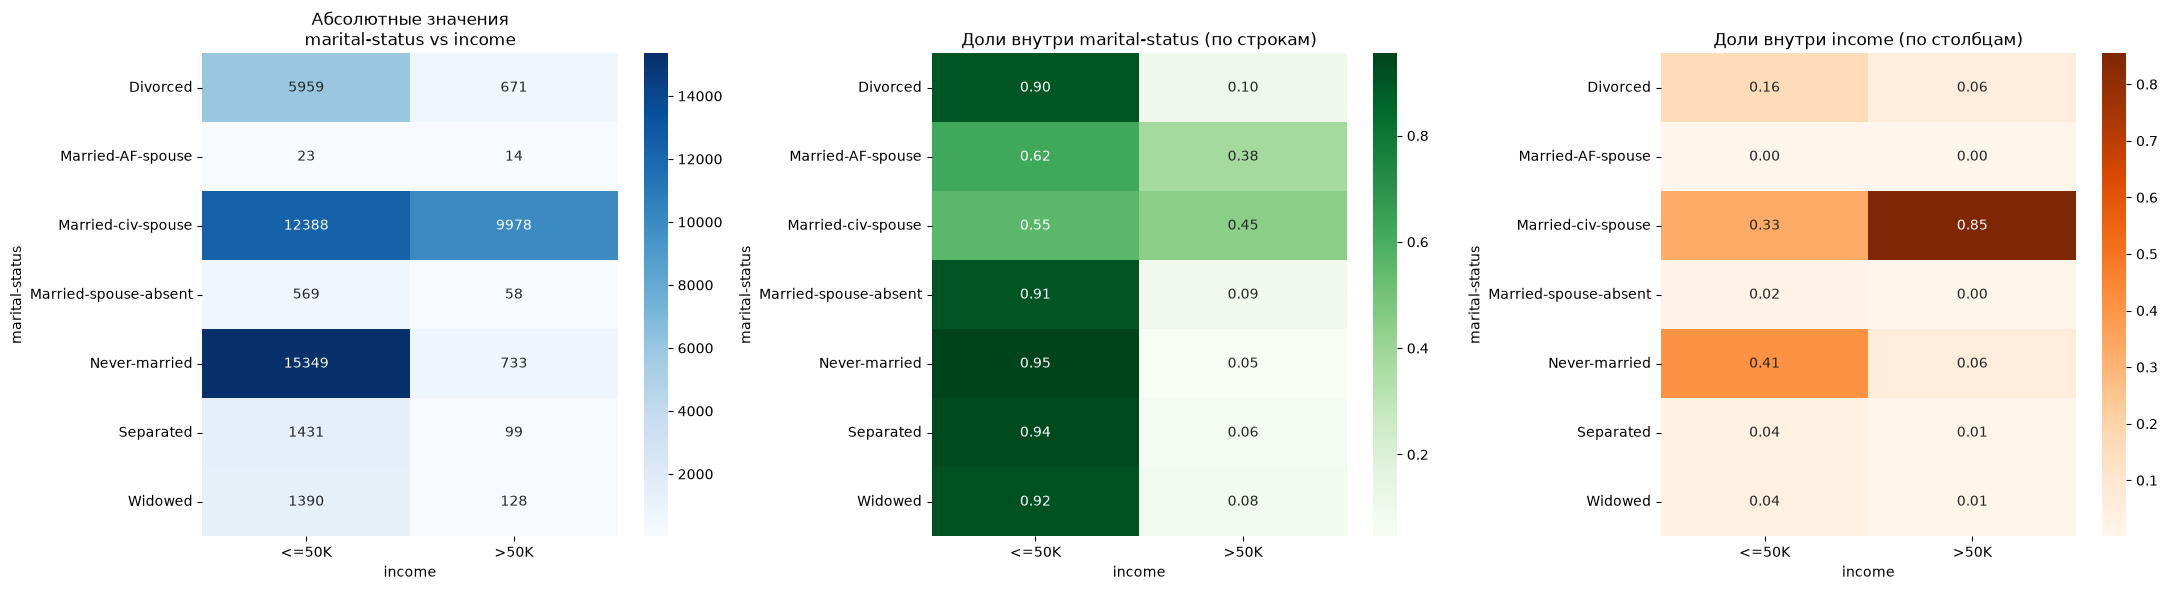

In [ ]:
plot_categorical_relationship(df, "marital-status", "income")

Те, кто больше получает, в основном женаты

#### 4.2.14 income vs occupation

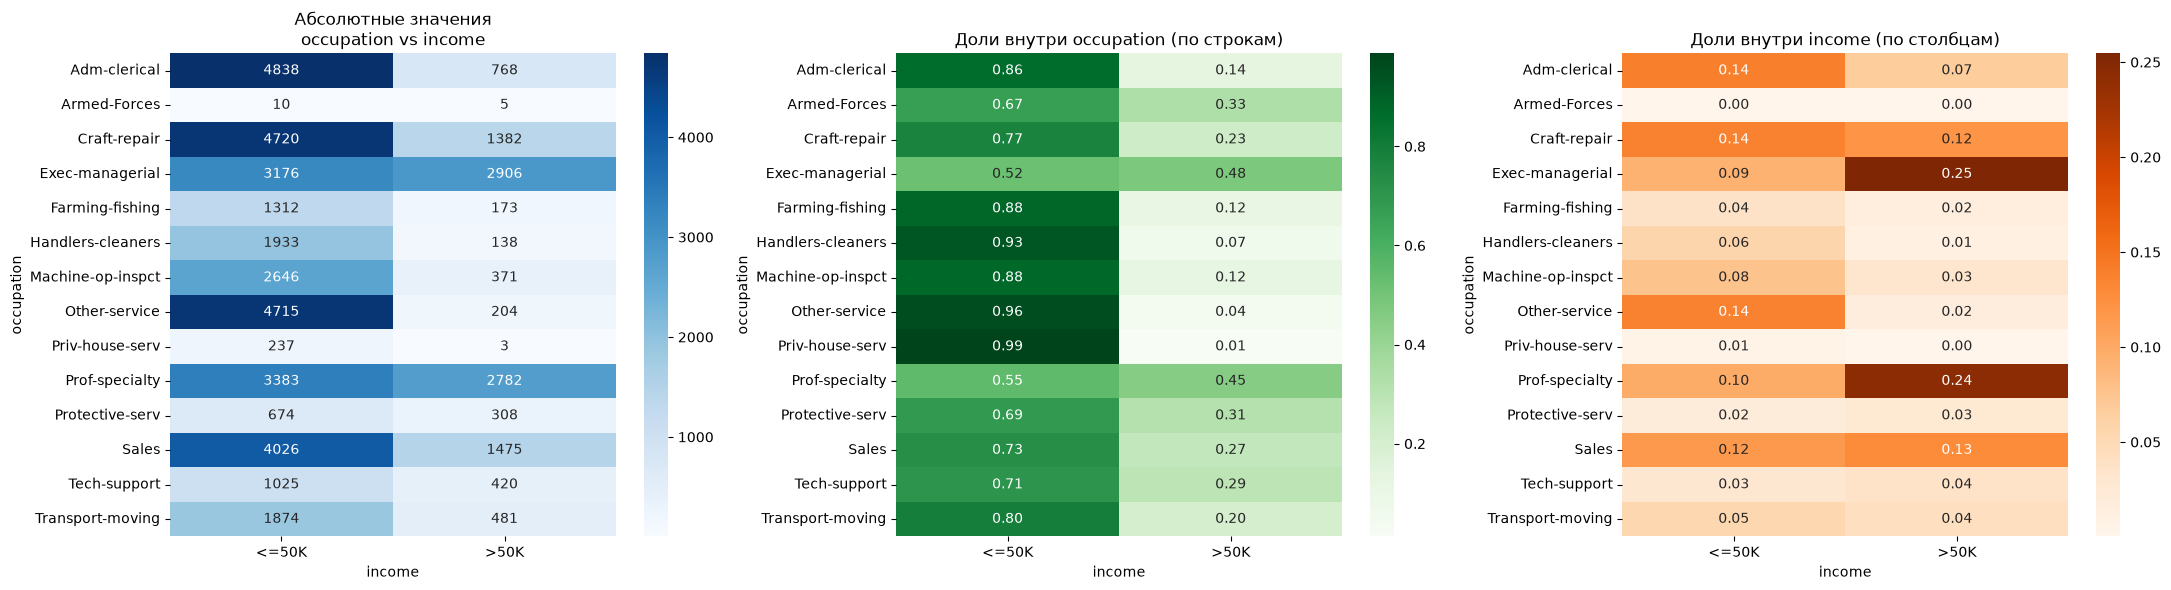

In [ ]:
plot_categorical_relationship(df, "occupation", "income")

Люди, которые занимают более престижные должности (exec / prof-specialty), больше зарабатывают

#### 4.2.15 income vs relationship

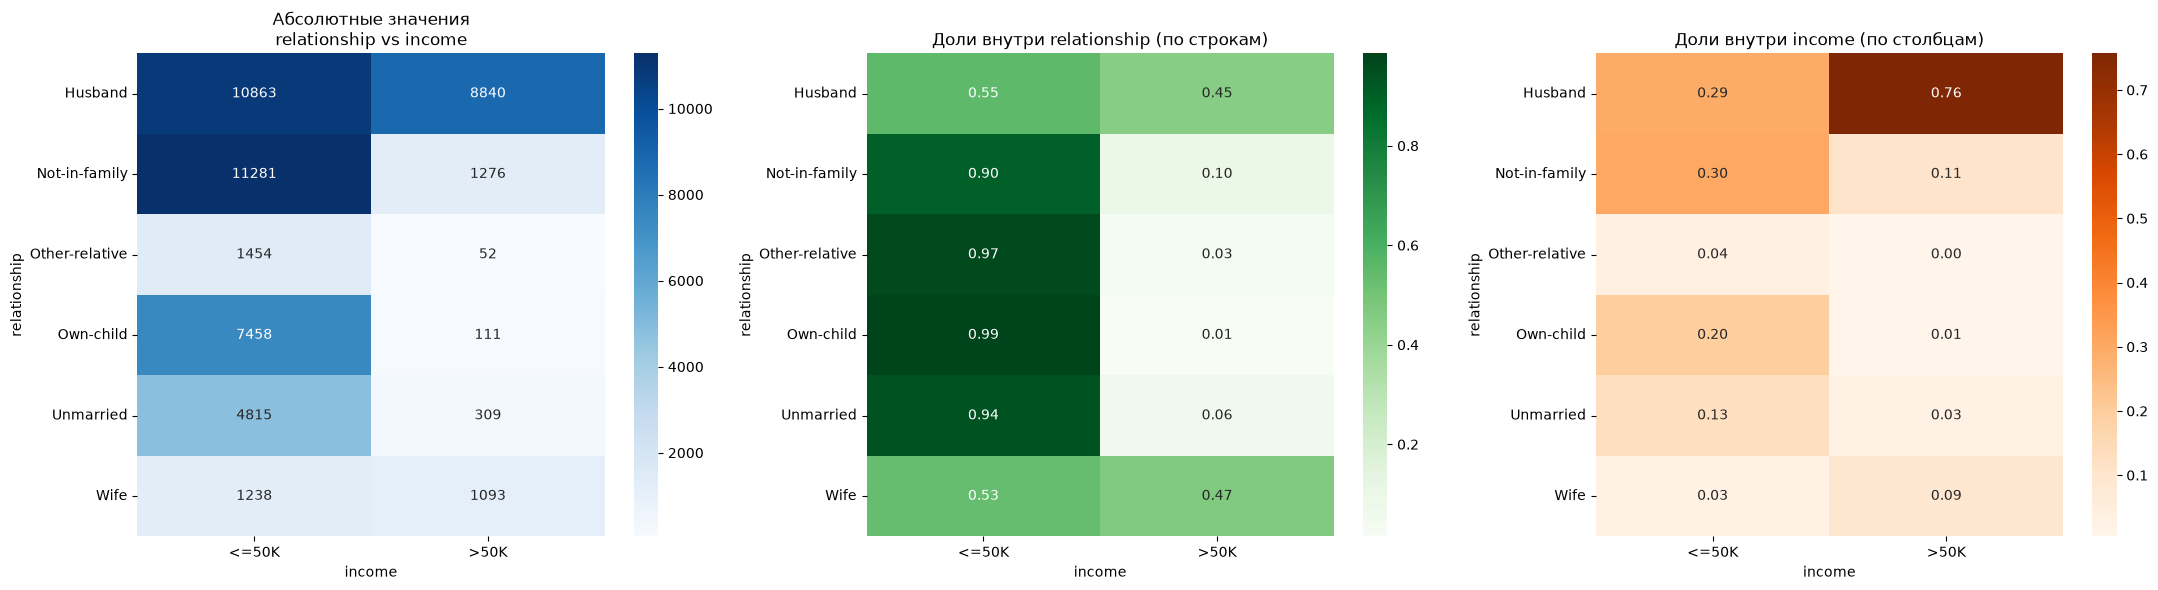

In [ ]:
plot_categorical_relationship(df, "relationship", "income")

- Быть мужем (Husband) - это категория с наиболее высокой долей людей, зарабатывающих >50K. 
- Все остальные категории (дети, другие родственники, не состоящие в браке) имеют значительно более низкий доход.